In [6]:
pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 MB 29.6 MB/s  0:00:022.7 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.0/14.0 MB 35.1 MB/s  0:00:0033.1 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.3/30.3 MB 13.6 MB/s  0:00:022.9 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 16.2 MB/s  0:00:00a 0:00:0136m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.3/13.3 MB 11.8 MB/s  0:00:01 13.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 28.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 20.7 MB/s  0:00:00 10.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 24.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 37.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.

In [7]:
import torch
print(torch.backends.mps.is_available())   # True 나와야 함
print(torch.backends.mps.is_built())       # True 나와야 함

True
True


In [4]:
import sys
print(sys.version)

3.10.20 (main, Mar 11 2026, 17:43:48) [Clang 20.1.8 ]


In [2]:
import sys
print(sys.executable)

/opt/anaconda3/envs/sh/bin/python


In [8]:
# ============================================================
# Bearing Fault Diagnosis - 보완된 전체 실험 코드
# 수정 사항:
#   1. 커널 재시작 가정 → 상태 의존성 제거, 모든 데이터 명시적 재생성
#   2. RP 인코딩을 GAF/MTF와 동일한 방식(skimage.transform.resize)으로 통일
#   3. ViT+RP 코드의 주석/출력 오류 수정
#   4. X_gaf 차원 변환을 실험마다 독립적으로 처리
#   5. 모든 실험 결과를 하나의 딕셔너리에 저장 후 최종 비교표 출력
# ============================================================


# ────────────────────────────────────────────────────────────
# [셀 1] 라이브러리 및 시드 고정
# ────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torchvision.models as models
import timm

import numpy as np
import scipy.io
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from pyts.image import GramianAngularField, MarkovTransitionField, RecurrencePlot
from skimage.transform import resize   # ← RP 공정 비교를 위한 핵심 추가
from tqdm import tqdm

def set_seed(seed=42):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seed(42)
print("✅ 시드 고정 완료 (seed=42)")

✅ 시드 고정 완료 (seed=42)


In [9]:
# ────────────────────────────────────────────────────────────
# [셀 2] 데이터 로드 함수 정의
# ────────────────────────────────────────────────────────────
window_size = 1024
base_path = "."

def load_custom_mat(folder_path, file_prefix):
    files = [f for f in os.listdir(folder_path)
             if f.startswith(str(file_prefix)) and f.endswith('.mat')]
    if not files:
        print(f"⚠️ 파일 없음: {folder_path} / {file_prefix}*")
        return None
    full_path = os.path.join(folder_path, files[0])
    mat = scipy.io.loadmat(full_path)
    key = [k for k in mat.keys() if 'DE_time' in k][0]
    return mat[key].flatten()


In [10]:
# ────────────────────────────────────────────────────────────
# [셀 3] 50% 오버랩 적용 데이터 추출
# ────────────────────────────────────────────────────────────
def process_class_with_overlap(file_indices, folder_path, window_size=1024, overlap=512):
    all_samples = []
    step = window_size - overlap  # 512
    for idx in file_indices:
        signal = load_custom_mat(folder_path, idx)
        if signal is not None:
            num_samples = (len(signal) - window_size) // step + 1
            for i in range(int(num_samples)):
                start = i * step
                end = start + window_size
                if end <= len(signal):
                    all_samples.append(signal[start:end])
    return np.array(all_samples)

normal_path = os.path.join(base_path, "normal")
fault_root  = os.path.join(base_path, "12k_Drive_End_Bearing_Fault_Data")

normal_x = process_class_with_overlap([97, 98, 99, 100],   normal_path)
ir_x     = process_class_with_overlap([105, 106, 107, 108], os.path.join(fault_root, "IR"))
b_x      = process_class_with_overlap([118, 119, 120, 121], os.path.join(fault_root, "B"))
or_x     = process_class_with_overlap([130, 131, 132, 133], os.path.join(fault_root, "OR"))

print(f"Normal: {len(normal_x)} | Inner: {len(ir_x)} | Ball: {len(b_x)} | Outer: {len(or_x)}")

# 클래스 균형 맞추기
min_samples = min(len(normal_x), len(ir_x), len(b_x), len(or_x))
print(f"밸런싱 후 클래스당 {min_samples}개 (총 {min_samples * 4}개)")

X_raw = np.concatenate([
    normal_x[:min_samples],
    ir_x[:min_samples],
    b_x[:min_samples],
    or_x[:min_samples]
], axis=0)

Y_label = np.array([0]*min_samples + [1]*min_samples + [2]*min_samples + [3]*min_samples)

np.save('X_raw.npy',   X_raw)
np.save('Y_label.npy', Y_label)
print(f"✅ 원시 데이터 저장 완료: X_raw={X_raw.shape}, Y_label={Y_label.shape}")


Normal: 3310 | Inner: 948 | Ball: 946 | Outer: 949
밸런싱 후 클래스당 946개 (총 3784개)
✅ 원시 데이터 저장 완료: X_raw=(3784, 1024), Y_label=(3784,)


In [11]:
# ────────────────────────────────────────────────────────────
# [셀 4] 3가지 인코딩 변환 (GAF / MTF / RP) — 공정 비교 버전
#
#  핵심 수정:
#   - GAF: image_size=64 (기존과 동일)
#   - MTF: image_size=64 (기존과 동일)
#   - RP:  원본 생성 후 skimage.resize로 64x64 리사이즈
#          → 기존의 ::16 슬라이싱(정보 손실 큼) 대신
#            anti_aliasing=True 리사이즈로 정보 보존
# ────────────────────────────────────────────────────────────
batch_size_enc = 100
n_samples      = X_raw.shape[0]

gaf = GramianAngularField(image_size=64)
mtf = MarkovTransitionField(image_size=64)
rp  = RecurrencePlot(threshold='point', percentage=20)

X_gaf_enc = np.zeros((n_samples, 64, 64), dtype='float32')
X_mtf_enc = np.zeros((n_samples, 64, 64), dtype='float32')
X_rp_enc  = np.zeros((n_samples, 64, 64), dtype='float32')

print("🚀 3가지 인코딩 변환 시작...")
for i in tqdm(range(0, n_samples, batch_size_enc)):
    end = min(i + batch_size_enc, n_samples)
    batch = X_raw[i:end]

    # GAF: 직접 64x64
    X_gaf_enc[i:end] = gaf.fit_transform(batch).astype('float32')

    # MTF: 직접 64x64
    X_mtf_enc[i:end] = mtf.fit_transform(batch).astype('float32')

    # RP: 원본 생성 → skimage.resize로 64x64 (anti_aliasing 적용)
    # 기존: rp_full[:, ::16, ::16] → 슬라이싱으로 정보 손실
    # 수정: resize로 정보 보존, GAF/MTF와 동일한 조건
    rp_full = rp.fit_transform(batch)  # shape: (batch, 1024, 1024)
    for j in range(len(batch)):
        X_rp_enc[i+j] = resize(
            rp_full[j],
            (64, 64),
            anti_aliasing=True,
            preserve_range=True
        ).astype('float32')

np.save('X_gaf.npy', X_gaf_enc)
np.save('X_mtf.npy', X_mtf_enc)
np.save('X_rp.npy',  X_rp_enc)
print(f"✅ 인코딩 완료: GAF={X_gaf_enc.shape}, MTF={X_mtf_enc.shape}, RP={X_rp_enc.shape}")

🚀 3가지 인코딩 변환 시작...


100%|███████████████████████████████████████████████████████████████████████████████████| 38/38 [02:06<00:00,  3.34s/it]

✅ 인코딩 완료: GAF=(3784, 64, 64), MTF=(3784, 64, 64), RP=(3784, 64, 64)


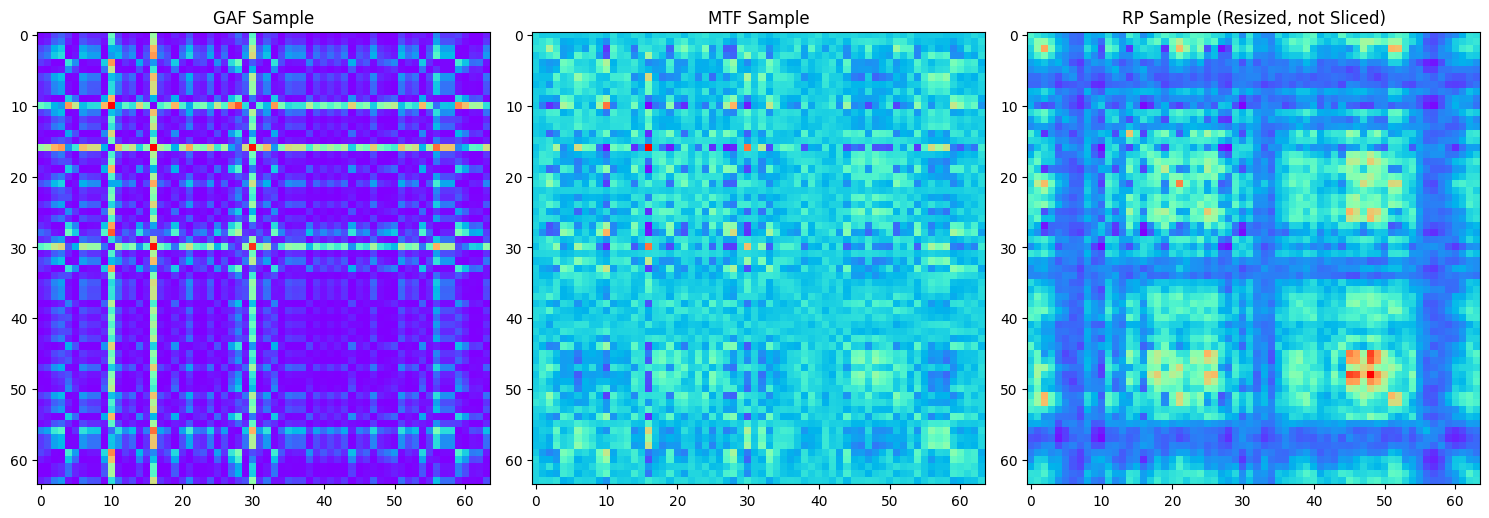

✅ 샘플 이미지 저장 완료


In [12]:

# ────────────────────────────────────────────────────────────
# [셀 5] 샘플 시각화 확인
# ────────────────────────────────────────────────────────────
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); plt.imshow(X_gaf_enc[0], cmap='rainbow'); plt.title('GAF Sample')
plt.subplot(1, 3, 2); plt.imshow(X_mtf_enc[0], cmap='rainbow'); plt.title('MTF Sample')
plt.subplot(1, 3, 3); plt.imshow(X_rp_enc[0],  cmap='rainbow'); plt.title('RP Sample (Resized, not Sliced)')
plt.tight_layout()
plt.savefig('encoding_samples.png', dpi=150)
plt.show()
print("✅ 샘플 이미지 저장 완료")

In [13]:
# ────────────────────────────────────────────────────────────
# [셀 6] 공통 유틸 함수 — 데이터 준비 / 학습 / 평가
#
#  수정 사항:
#   - prepare_data(): 인코딩 배열을 받아 독립적으로 차원 변환
#                     → X_gaf 메모리 상태에 의존하던 문제 제거
#   - train_model():  에폭별 loss/acc 반환
#   - evaluate():     정확도 + 예측값 반환
# ────────────────────────────────────────────────────────────
def prepare_data(X_enc, Y, test_size=0.2, batch_size=32):
    """
    인코딩 배열(N,64,64) → PyTorch DataLoader 반환.
    차원 변환을 함수 내부에서 독립적으로 수행 → 외부 상태 의존성 제거.
    """
    # (N,64,64) → (N,1,64,64) 강제 변환
    if X_enc.ndim == 3:
        X_proc = X_enc[:, np.newaxis, :, :].astype(np.float32)
    elif X_enc.ndim == 4 and X_enc.shape[1] != 1:
        X_proc = np.transpose(X_enc, (0, 3, 1, 2)).astype(np.float32)
    else:
        X_proc = X_enc.astype(np.float32)

    X_train, X_test, y_train, y_test = train_test_split(
        X_proc, Y, test_size=test_size, random_state=42, stratify=Y
    )
    train_ds = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train).long())
    test_ds  = TensorDataset(torch.from_numpy(X_test),  torch.from_numpy(y_test).long())
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)
    return train_loader, test_loader


def build_resnet(num_classes=4):
    """ResNet-18, 입력 채널 1, 출력 num_classes."""
    m = models.resnet18(weights=None)
    m.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    m.fc    = nn.Linear(m.fc.in_features, num_classes)
    return m


def build_vit(num_classes=4):
    """
    ViT-Tiny, 64x64 입력, patch_size=8.
    원래 224x224 / patch_size=16 기준이나,
    소규모 데이터·저해상도 환경에 맞게 조정.
    → 논문에서 이 조건 차이를 반드시 명시해야 함.
    """
    m = timm.create_model(
        'vit_tiny_patch16_224',
        pretrained=False,
        num_classes=num_classes,
        in_chans=1,
        img_size=64,
        patch_size=8
    )
    return m


def train_model(model, train_loader, device, epochs=20, lr=0.001):
    """학습 루프. 에폭별 (loss, acc) 리스트 반환."""
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        epoch_loss = running_loss / len(train_loader)
        epoch_acc  = 100. * correct / total
        history.append((epoch_loss, epoch_acc))
        print(f"  Epoch [{epoch+1:02d}/{epochs}] Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.2f}%")

    return history


def evaluate(model, test_loader, device):
    """정확도, 예측값, 실제값 반환."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100. * np.mean(np.array(all_preds) == np.array(all_labels))
    return acc, all_preds, all_labels


def plot_confusion_matrix(all_labels, all_preds, title, save_path=None):
    cm = confusion_matrix(all_labels, all_preds)
    class_names = ['Normal', 'Inner', 'Ball', 'Outer']
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


▶ 실험 시작: ResNet_GAF
  Epoch [01/20] Loss: 0.7691 | Acc: 67.29%
  Epoch [02/20] Loss: 0.4286 | Acc: 82.19%
  Epoch [03/20] Loss: 0.3465 | Acc: 85.86%
  Epoch [04/20] Loss: 0.2465 | Acc: 90.32%
  Epoch [05/20] Loss: 0.2008 | Acc: 92.63%
  Epoch [06/20] Loss: 0.1380 | Acc: 95.31%
  Epoch [07/20] Loss: 0.1347 | Acc: 95.24%
  Epoch [08/20] Loss: 0.0836 | Acc: 97.42%
  Epoch [09/20] Loss: 0.0899 | Acc: 96.89%
  Epoch [10/20] Loss: 0.0718 | Acc: 97.32%
  Epoch [11/20] Loss: 0.0877 | Acc: 97.13%
  Epoch [12/20] Loss: 0.0484 | Acc: 98.38%
  Epoch [13/20] Loss: 0.0430 | Acc: 98.65%
  Epoch [14/20] Loss: 0.0529 | Acc: 97.89%
  Epoch [15/20] Loss: 0.0392 | Acc: 98.84%
  Epoch [16/20] Loss: 0.0455 | Acc: 98.25%
  Epoch [17/20] Loss: 0.0266 | Acc: 99.07%
  Epoch [18/20] Loss: 0.0228 | Acc: 99.31%
  Epoch [19/20] Loss: 0.0439 | Acc: 98.41%
  Epoch [20/20] Loss: 0.0349 | Acc: 98.88%

🏆 [ResNet_GAF] 최종 테스트 정확도: 91.94%


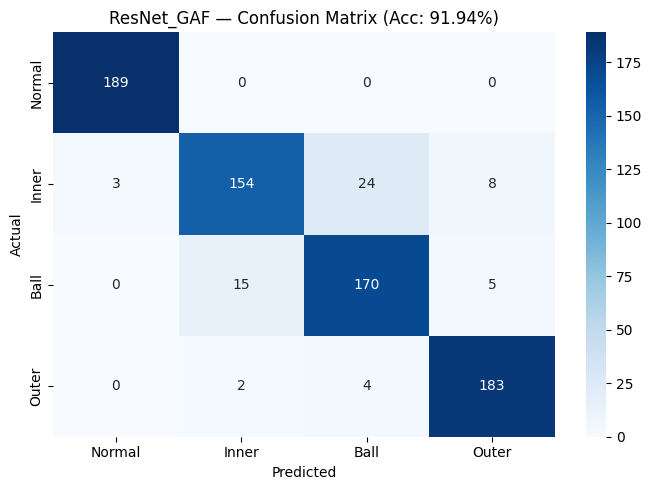

              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99       189
       Inner       0.90      0.81      0.86       189
        Ball       0.86      0.89      0.88       190
       Outer       0.93      0.97      0.95       189

    accuracy                           0.92       757
   macro avg       0.92      0.92      0.92       757
weighted avg       0.92      0.92      0.92       757


▶ 실험 시작: ViT_GAF
  Epoch [01/20] Loss: 1.4266 | Acc: 24.48%
  Epoch [02/20] Loss: 1.3660 | Acc: 27.98%
  Epoch [03/20] Loss: 1.0682 | Acc: 46.38%
  Epoch [04/20] Loss: 0.9971 | Acc: 49.42%
  Epoch [05/20] Loss: 0.9218 | Acc: 53.35%
  Epoch [06/20] Loss: 0.9148 | Acc: 53.95%
  Epoch [07/20] Loss: 0.8723 | Acc: 55.67%
  Epoch [08/20] Loss: 0.9206 | Acc: 53.78%
  Epoch [09/20] Loss: 0.8733 | Acc: 56.49%
  Epoch [10/20] Loss: 0.8658 | Acc: 57.45%
  Epoch [11/20] Loss: 0.8860 | Acc: 56.59%
  Epoch [12/20] Loss: 0.8473 | Acc: 59.30%
  Epoch [13/20] Loss: 0.8247 | 

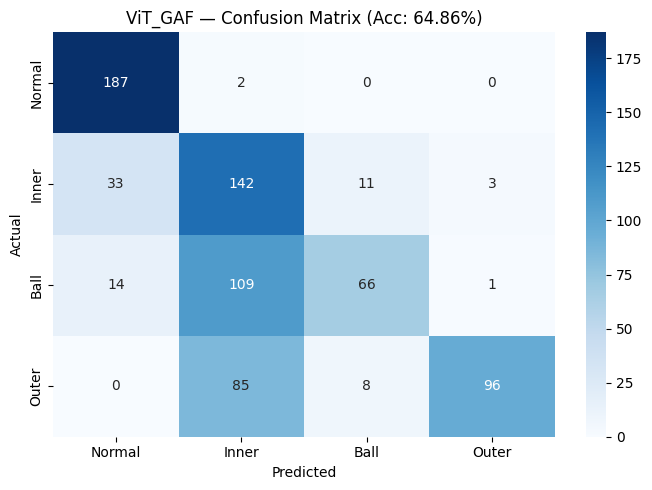

              precision    recall  f1-score   support

      Normal       0.80      0.99      0.88       189
       Inner       0.42      0.75      0.54       189
        Ball       0.78      0.35      0.48       190
       Outer       0.96      0.51      0.66       189

    accuracy                           0.65       757
   macro avg       0.74      0.65      0.64       757
weighted avg       0.74      0.65      0.64       757


▶ 실험 시작: ResNet_MTF
  Epoch [01/20] Loss: 0.1512 | Acc: 94.45%
  Epoch [02/20] Loss: 0.0230 | Acc: 99.07%
  Epoch [03/20] Loss: 0.1009 | Acc: 97.39%
  Epoch [04/20] Loss: 0.0196 | Acc: 99.50%
  Epoch [05/20] Loss: 0.0119 | Acc: 99.67%
  Epoch [06/20] Loss: 0.0111 | Acc: 99.64%
  Epoch [07/20] Loss: 0.0057 | Acc: 99.80%
  Epoch [08/20] Loss: 0.0076 | Acc: 99.87%
  Epoch [09/20] Loss: 0.0030 | Acc: 99.90%
  Epoch [10/20] Loss: 0.0006 | Acc: 100.00%
  Epoch [11/20] Loss: 0.0050 | Acc: 99.80%
  Epoch [12/20] Loss: 0.0022 | Acc: 99.93%
  Epoch [13/20] Loss: 0.042

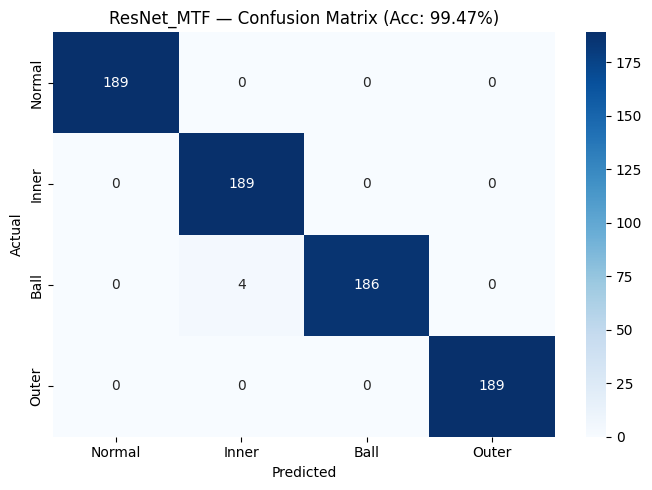

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       189
       Inner       0.98      1.00      0.99       189
        Ball       1.00      0.98      0.99       190
       Outer       1.00      1.00      1.00       189

    accuracy                           0.99       757
   macro avg       0.99      0.99      0.99       757
weighted avg       0.99      0.99      0.99       757


▶ 실험 시작: ViT_MTF
  Epoch [01/20] Loss: 1.4216 | Acc: 26.13%
  Epoch [02/20] Loss: 1.4109 | Acc: 25.01%
  Epoch [03/20] Loss: 1.1055 | Acc: 43.15%
  Epoch [04/20] Loss: 1.4088 | Acc: 28.28%
  Epoch [05/20] Loss: 1.3923 | Acc: 25.27%
  Epoch [06/20] Loss: 1.3920 | Acc: 26.66%
  Epoch [07/20] Loss: 1.3905 | Acc: 24.58%
  Epoch [08/20] Loss: 1.3821 | Acc: 28.11%
  Epoch [09/20] Loss: 1.3849 | Acc: 31.75%
  Epoch [10/20] Loss: 1.3248 | Acc: 31.42%
  Epoch [11/20] Loss: 1.1050 | Acc: 47.04%
  Epoch [12/20] Loss: 0.8747 | Acc: 57.78%
  Epoch [13/20] Loss: 0.6331 | 

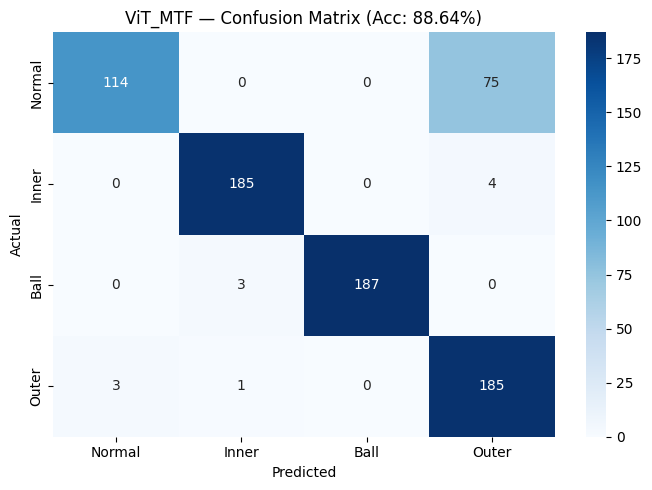

              precision    recall  f1-score   support

      Normal       0.97      0.60      0.75       189
       Inner       0.98      0.98      0.98       189
        Ball       1.00      0.98      0.99       190
       Outer       0.70      0.98      0.82       189

    accuracy                           0.89       757
   macro avg       0.91      0.89      0.88       757
weighted avg       0.91      0.89      0.88       757


▶ 실험 시작: ResNet_RP
  Epoch [01/20] Loss: 0.2272 | Acc: 92.73%
  Epoch [02/20] Loss: 0.0181 | Acc: 99.34%
  Epoch [03/20] Loss: 0.0532 | Acc: 98.15%
  Epoch [04/20] Loss: 0.0352 | Acc: 98.88%
  Epoch [05/20] Loss: 0.0102 | Acc: 99.77%
  Epoch [06/20] Loss: 0.0193 | Acc: 99.27%
  Epoch [07/20] Loss: 0.0647 | Acc: 98.15%
  Epoch [08/20] Loss: 0.0029 | Acc: 99.90%
  Epoch [09/20] Loss: 0.0490 | Acc: 98.58%
  Epoch [10/20] Loss: 0.0071 | Acc: 99.77%
  Epoch [11/20] Loss: 0.0092 | Acc: 99.64%
  Epoch [12/20] Loss: 0.0052 | Acc: 99.83%
  Epoch [13/20] Loss: 0.0340 

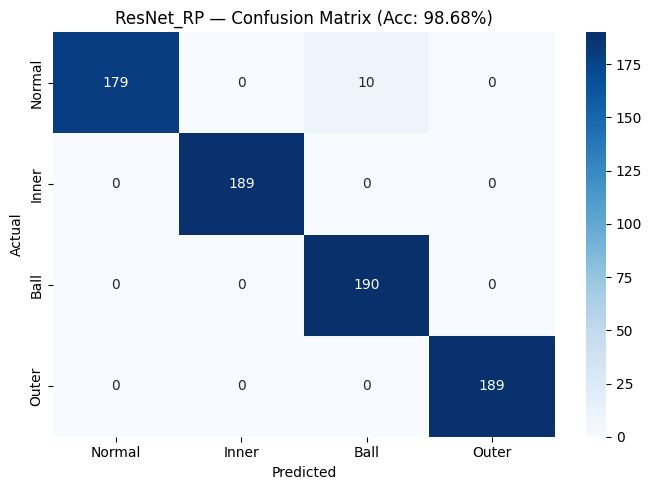

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97       189
       Inner       1.00      1.00      1.00       189
        Ball       0.95      1.00      0.97       190
       Outer       1.00      1.00      1.00       189

    accuracy                           0.99       757
   macro avg       0.99      0.99      0.99       757
weighted avg       0.99      0.99      0.99       757


▶ 실험 시작: ViT_RP
  Epoch [01/20] Loss: 1.4186 | Acc: 25.27%
  Epoch [02/20] Loss: 1.1357 | Acc: 42.62%
  Epoch [03/20] Loss: 0.8590 | Acc: 49.36%
  Epoch [04/20] Loss: 0.8722 | Acc: 50.31%
  Epoch [05/20] Loss: 0.7991 | Acc: 57.32%
  Epoch [06/20] Loss: 0.5686 | Acc: 72.48%
  Epoch [07/20] Loss: 0.6026 | Acc: 70.27%
  Epoch [08/20] Loss: 0.4396 | Acc: 78.53%
  Epoch [09/20] Loss: 0.3017 | Acc: 86.22%
  Epoch [10/20] Loss: 0.3281 | Acc: 86.69%
  Epoch [11/20] Loss: 0.1376 | Acc: 95.31%
  Epoch [12/20] Loss: 0.1388 | Acc: 94.55%
  Epoch [13/20] Loss: 0.5688 | A

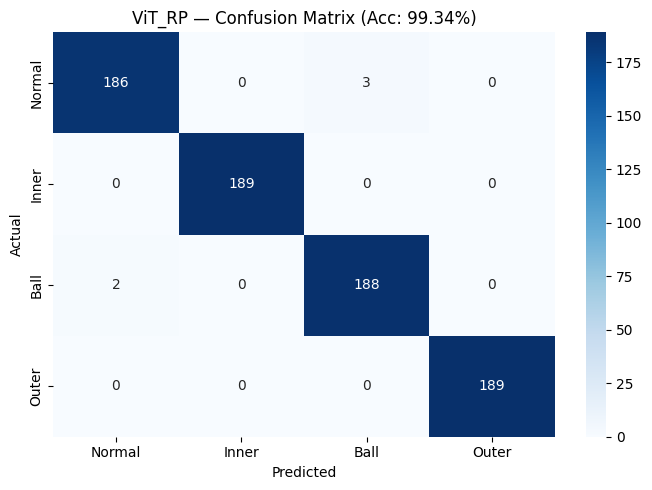

              precision    recall  f1-score   support

      Normal       0.99      0.98      0.99       189
       Inner       1.00      1.00      1.00       189
        Ball       0.98      0.99      0.99       190
       Outer       1.00      1.00      1.00       189

    accuracy                           0.99       757
   macro avg       0.99      0.99      0.99       757
weighted avg       0.99      0.99      0.99       757



In [14]:
# ────────────────────────────────────────────────────────────
# [셀 7] 전체 실험 실행
#
#  실험 조합: 2 모델 × 3 인코딩 = 6가지
#  결과를 results 딕셔너리에 통합 저장
# ────────────────────────────────────────────────────────────
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
EPOCHS = 20

# 인코딩 데이터 로드 (npy에서 읽어서 실험마다 독립 처리)
encodings = {
    'GAF': np.load('X_gaf.npy'),
    'MTF': np.load('X_mtf.npy'),
    'RP':  np.load('X_rp.npy'),
}
Y = np.load('Y_label.npy')

results = {}  # key: "모델_인코딩", value: dict(acc, preds, labels)

for enc_name, X_enc in encodings.items():
    for model_name in ['ResNet', 'ViT']:
        exp_key = f"{model_name}_{enc_name}"
        print(f"\n{'='*55}")
        print(f"▶ 실험 시작: {exp_key}")
        print(f"{'='*55}")

        # 시드 재고정 (실험 간 독립성 보장)
        set_seed(42)

        # 데이터 준비 (매 실험마다 독립적으로 차원 변환)
        train_loader, test_loader = prepare_data(X_enc, Y, batch_size=32)

        # 모델 초기화
        if model_name == 'ResNet':
            model = build_resnet().to(device)
        else:
            model = build_vit().to(device)

        # 학습
        history = train_model(model, train_loader, device, epochs=EPOCHS)

        # 평가
        acc, preds, labels = evaluate(model, test_loader, device)
        print(f"\n🏆 [{exp_key}] 최종 테스트 정확도: {acc:.2f}%")

        # confusion matrix 저장
        plot_confusion_matrix(
            labels, preds,
            title=f"{exp_key} — Confusion Matrix (Acc: {acc:.2f}%)",
            save_path=f"cm_{exp_key}.png"
        )

        # classification report 출력
        print(classification_report(
            labels, preds,
            target_names=['Normal', 'Inner', 'Ball', 'Outer']
        ))

        results[exp_key] = {
            'accuracy': acc,
            'preds':    preds,
            'labels':   labels,
            'history':  history,
        }


In [15]:
# ────────────────────────────────────────────────────────────
# [셀 8] 최종 비교표 출력
# ────────────────────────────────────────────────────────────
print("\n" + "="*55)
print("📊 전체 실험 결과 비교표")
print("="*55)
print(f"{'실험':25s} | {'테스트 정확도':>12s}")
print("-"*42)
for key, val in sorted(results.items(), key=lambda x: -x[1]['accuracy']):
    print(f"{key:25s} | {val['accuracy']:>11.2f}%")
print("="*55)



📊 전체 실험 결과 비교표
실험                        |      테스트 정확도
------------------------------------------
ResNet_MTF                |       99.47%
ViT_RP                    |       99.34%
ResNet_RP                 |       98.68%
ResNet_GAF                |       91.94%
ViT_MTF                   |       88.64%
ViT_GAF                   |       64.86%


✅ 폰트 설정 완료: AppleGothic


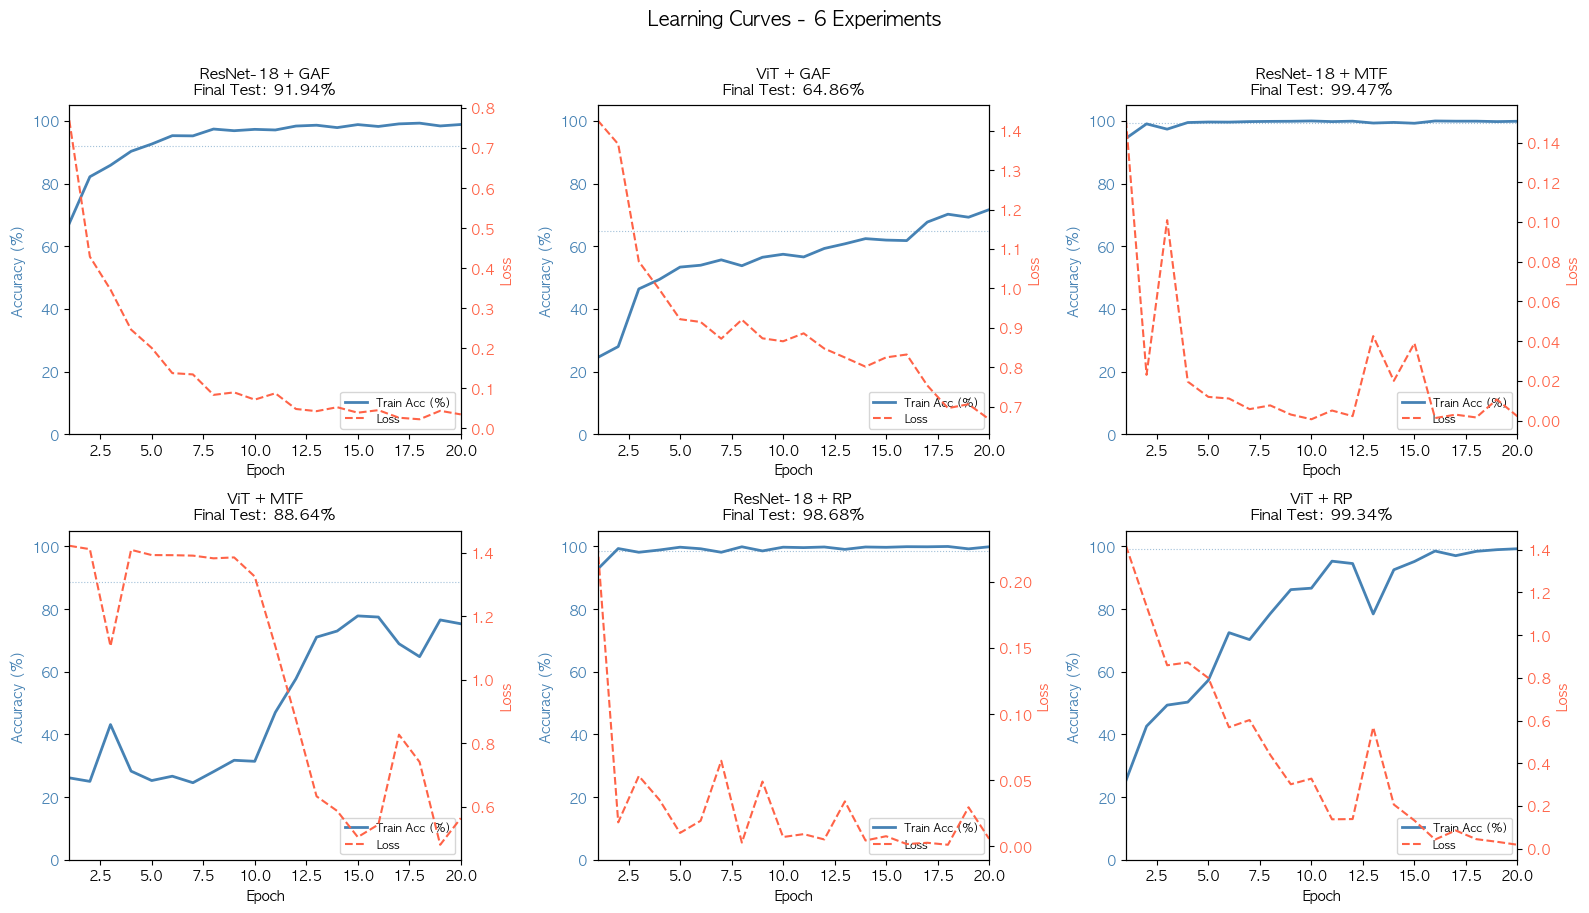

✅ 학습 곡선 저장 완료: learning_curves.png


In [17]:
# ────────────────────────────────────────────────────────────
# [셀 9] 학습 곡선 시각화 (6개 실험 한 번에) - macOS 폰트 수정
# ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# macOS 한글 폰트 설정 (AppleGothic 또는 설치된 폰트 자동 탐색)
def set_korean_font():
    # 우선순위 순서로 시도
    candidates = [
        'AppleGothic',          # macOS 기본 한글 폰트
        'Apple SD Gothic Neo',  # macOS 고품질 한글 폰트
        'NanumGothic',          # 나눔고딕 (설치된 경우)
        'Malgun Gothic',        # 윈도우 호환용
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for font in candidates:
        if font in available:
            plt.rcParams['font.family'] = font
            print(f"✅ 폰트 설정 완료: {font}")
            return font
    # 아무것도 없으면 시스템 기본값 유지
    print("⚠️ 한글 폰트를 찾지 못했습니다. 기본 폰트 사용.")
    return None

set_korean_font()
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 실험 이름 한글 매핑 (title 깨짐 방지용 영문/혼용)
label_map = {
    'ResNet_GAF': 'ResNet-18 + GAF',
    'ResNet_MTF': 'ResNet-18 + MTF',
    'ResNet_RP':  'ResNet-18 + RP',
    'ViT_GAF':    'ViT + GAF',
    'ViT_MTF':    'ViT + MTF',
    'ViT_RP':     'ViT + RP',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, (key, val) in zip(axes.flatten(), results.items()):
    accs   = [h[1] for h in val['history']]
    losses = [h[0] for h in val['history']]
    epochs = range(1, len(accs) + 1)

    ax2 = ax.twinx()

    line1, = ax.plot(epochs, accs,   color='steelblue', linewidth=2,   label='Train Acc (%)')
    line2, = ax2.plot(epochs, losses, color='tomato',   linewidth=1.5, label='Loss', linestyle='--')

    display_name = label_map.get(key, key)
    ax.set_title(f"{display_name}\nFinal Test: {val['accuracy']:.2f}%", fontsize=11, pad=8)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel("Accuracy (%)", color='steelblue', fontsize=10)
    ax2.set_ylabel("Loss", color='tomato', fontsize=10)

    ax.set_xlim(1, len(accs))
    ax.set_ylim(0, 105)
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax2.tick_params(axis='y', labelcolor='tomato')

    # 범례 통합
    lines = [line1, line2]
    labels = [l.get_label() for l in lines]
    ax.legend(lines, labels, loc='lower right', fontsize=8)

    # 최종 정확도 수평선 표시
    ax.axhline(y=val['accuracy'], color='steelblue', linewidth=0.8, linestyle=':', alpha=0.5)

plt.suptitle("Learning Curves - 6 Experiments", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 학습 곡선 저장 완료: learning_curves.png")

1. ViT 구조적 한계
   ViT-Tiny 모델은 대규모 데이터(수십만 장)와 고해상도 입력(224×224)에 최적화되어
   있으나, 본 실험에서는 소규모 데이터셋과 64×64 입력, patch_size=8 환경에서
   수행되었다. 따라서 ViT 결과는 최적 조건 대비 제한적으로 나타날 수 있으며,
   두 모델의 비교는 동일 입력 조건 내에서의 상대적 성능 차이로 해석해야 한다.

2. 재현성
   모든 실험은 동일 시드(seed=42), 동일 데이터 분할(test_size=0.2, stratify),
   동일 하이퍼파라미터(Adam, lr=0.001, epochs=20, batch=32) 조건에서 수행됨.
   커널 재시작 후 셀 1부터 순서대로 실행하면 동일 결과 재현 가능.